In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# ======================================================
# Directories
# ======================================================

DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# ======================================================
# Columns & targets
# ======================================================

EXCLUDE_COLS = [
    "StartDateTime", "EndDateTime",
    "Perf_Filename", "ND_Filename",
    "RunDateTime"
]

TARGETS = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss",
}


# ======================================================
# Utility Functions
# ======================================================

def load_split_data():
    """Loads train/valid/test CSVs."""
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test


def extract_xy(df):
    """Auto-detect numeric features & extract targets."""
    df = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns], errors="ignore")
    df_num = df.select_dtypes(include=[np.number])

    feature_cols = [c for c in df_num.columns if c not in TARGETS.values()]
    X = df_num[feature_cols].fillna(0)

    y = {name: df_num[col].fillna(0) for name, col in TARGETS.items()}
    return X, y, feature_cols


# ======================================================
# RF Training for a Single Target
# ======================================================

def train_rf_single(X_train, X_valid, X_test, y_train, y_valid, y_test, model_name):
    """
    Train & evaluate RF for a single metric (throughput, latency, loss).
    """

    print(f"\n====================== RF MODEL: {model_name} ======================")

    # Random Forest model (tune if necessary)
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Save model
    model_path = os.path.join(MODEL_DIR, f"rf_model_{model_name.lower()}.pkl")
    joblib.dump(model, model_path)
    print(f"Saved RF model → {model_path}")

    # Predictions
    y_valid_pred = model.predict(X_valid)
    y_test_pred  = model.predict(X_test)

    # Validation metrics
    val_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    val_mae  = mean_absolute_error(y_valid, y_valid_pred)
    val_r2   = r2_score(y_valid, y_valid_pred)

    # Test metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae  = mean_absolute_error(y_test, y_test_pred)
    test_r2   = r2_score(y_test, y_test_pred)

    print("Validation:")
    print(f"  RMSE: {val_rmse:.4f},  MAE: {val_mae:.4f},  R²: {val_r2:.4f}")

    print("Test:")
    print(f"  RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")

    # Save predictions
    pred_valid_path = os.path.join(PRED_DIR, f"rf_{model_name}_valid_predictions.csv")
    pred_test_path  = os.path.join(PRED_DIR, f"rf_{model_name}_test_predictions.csv")

    pd.DataFrame({"y_true": y_valid, "y_pred": y_valid_pred}).to_csv(pred_valid_path, index=False)
    pd.DataFrame({"y_true": y_test,  "y_pred": y_test_pred}).to_csv(pred_test_path, index=False)

    print(f"Validation predictions saved → {pred_valid_path}")
    print(f"Test predictions saved → {pred_test_path}")

    return {
        "Model": model_name,
        "Val_RMSE": val_rmse,
        "Val_MAE": val_mae,
        "Val_R2": val_r2,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2
    }


# ======================================================
# Full RF Pipeline
# ======================================================

def train_rf_pipeline():
    df_train, df_valid, df_test = load_split_data()

    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _ = extract_xy(df_valid)
    X_test,  y_test_dict, _  = extract_xy(df_test)

    results = []

    for model_name in TARGETS.keys():
        res = train_rf_single(
            X_train, X_valid, X_test,
            y_train_dict[model_name],
            y_valid_dict[model_name],
            y_test_dict[model_name],
            model_name
        )
        results.append(res)

    print("\n=================== RF FINAL SUMMARY ===================")
    for r in results:
        print(r)

    return results


# ======================================================
# RUN
# ======================================================

if __name__ == "__main__":
    train_rf_pipeline()



====================== RF MODEL: Throughput ======================
Saved RF model → ../outputs/models/rf_model_throughput.pkl
Validation:
  RMSE: 0.0075,  MAE: 0.0066,  R²: 0.0000
Test:
  RMSE: 0.0933, MAE: 0.0933, R²: 0.0000
Validation predictions saved → ../outputs/models/predictions/rf_Throughput_valid_predictions.csv
Test predictions saved → ../outputs/models/predictions/rf_Throughput_test_predictions.csv

====================== RF MODEL: Latency ======================
Saved RF model → ../outputs/models/rf_model_latency.pkl
Validation:
  RMSE: 1.7856,  MAE: 1.7848,  R²: 0.0000
Test:
  RMSE: 3.3953, MAE: 3.3952, R²: 0.0000
Validation predictions saved → ../outputs/models/predictions/rf_Latency_valid_predictions.csv
Test predictions saved → ../outputs/models/predictions/rf_Latency_test_predictions.csv

====================== RF MODEL: Loss ======================
Saved RF model → ../outputs/models/rf_model_loss.pkl
Validation:
  RMSE: 0.1581,  MAE: 0.1527,  R²: 0.0000
Test:
  RMSE: 5

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"

os.makedirs(PLOT_DIR, exist_ok=True)

MODELS = ["Throughput", "Latency", "Loss"]

plt.style.use("seaborn-v0_8-whitegrid")


# ============================================================
# 1. Load RF Predictions
# ============================================================

def load_rf_predictions(model_name, split):
    """
    split ∈ {"valid", "test"}
    """
    path = os.path.join(PRED_DIR, f"rf_{model_name}_{split}_predictions.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing RF prediction file → {path}")

    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


# ============================================================
# 2. Scatter Plot: Predicted vs Actual
# ============================================================

def plot_pred_vs_actual(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(7, 6))

    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, edgecolor=None)

    # Identity line
    lo = min(min(y_true), min(y_pred))
    hi = max(max(y_true), max(y_pred))
    plt.plot([lo, hi], [lo, hi], 'r--', label="Ideal")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    if showImage:
        plt.show()
    else:
        plt.close()

    print(f"Saved → {outfile}")


# ============================================================
# 3. Time-Series Line Plot
# ============================================================

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):

    plt.figure(figsize=(10, 5))

    plt.plot(y_true.values, label="Actual", color="blue", linewidth=2)
    plt.plot(y_pred, label="Predicted", color="orange", linestyle="--", linewidth=2)

    plt.title(title)
    plt.xlabel("Sample Index (Interval Order)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    if showImage:
        plt.show()
    else:
        plt.close()

    print(f"Saved → {outfile}")


# ============================================================
# 4. Generate All Plots
# ============================================================

def generate_rf_plots(showImage=False):

    for model_name in MODELS:
        print(f"\n=== RF Plots for {model_name} ===")

        # -------------------------
        # Validation plots
        # -------------------------
        yv, yv_pred = load_rf_predictions(model_name, "valid")

        # Scatter
        out_valid_scatter = os.path.join(
            PLOT_DIR, f"rf_{model_name}_pred_vs_actual_valid.png"
        )
        plot_pred_vs_actual(
            yv, yv_pred,
            title=f"RF {model_name} – Predicted vs Actual (Validation)",
            outfile=out_valid_scatter,
            showImage=showImage
        )

        # Time-series
        out_valid_ts = os.path.join(
            PLOT_DIR, f"rf_{model_name}_timeseries_valid.png"
        )
        plot_time_series(
            yv, yv_pred,
            title=f"RF {model_name} – Time-Series (Validation)",
            outfile=out_valid_ts,
            showImage=showImage
        )

        # -------------------------
        # Test plots
        # -------------------------
        yt, yt_pred = load_rf_predictions(model_name, "test")

        # Scatter
        out_test_scatter = os.path.join(
            PLOT_DIR, f"rf_{model_name}_pred_vs_actual_test.png"
        )
        plot_pred_vs_actual(
            yt, yt_pred,
            title=f"RF {model_name} – Predicted vs Actual (Test)",
            outfile=out_test_scatter,
            showImage=showImage
        )

        # Time-series
        out_test_ts = os.path.join(
            PLOT_DIR, f"rf_{model_name}_timeseries_test.png"
        )
        plot_time_series(
            yt, yt_pred,
            title=f"RF {model_name} – Time-Series (Test)",
            outfile=out_test_ts,
            showImage=showImage
        )

    print("\nAll RF plots generated!")



=== RF Plots for Throughput ===


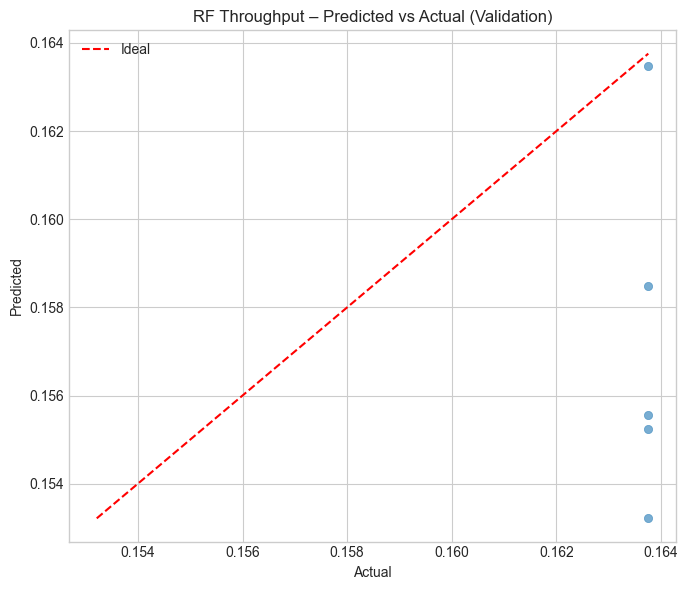

Saved → ../outputs/models/plots/rf_Throughput_pred_vs_actual_valid.png


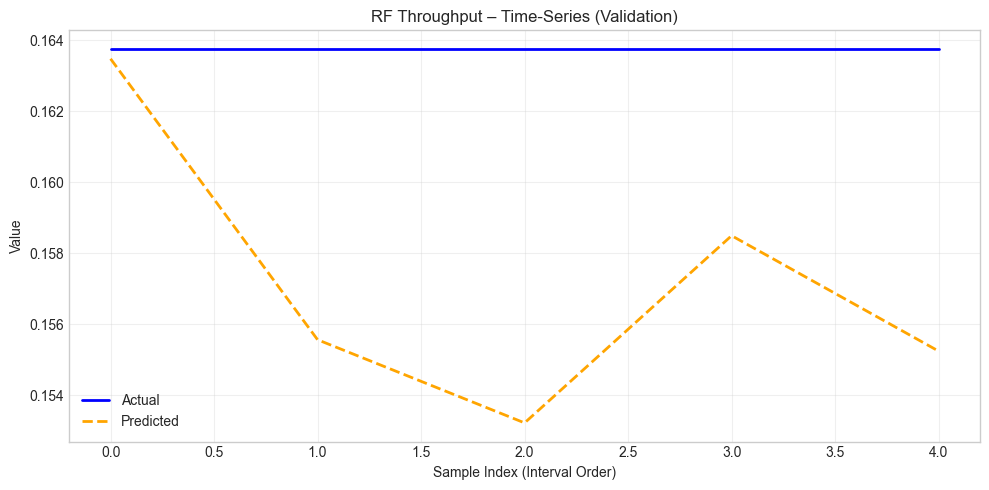

Saved → ../outputs/models/plots/rf_Throughput_timeseries_valid.png


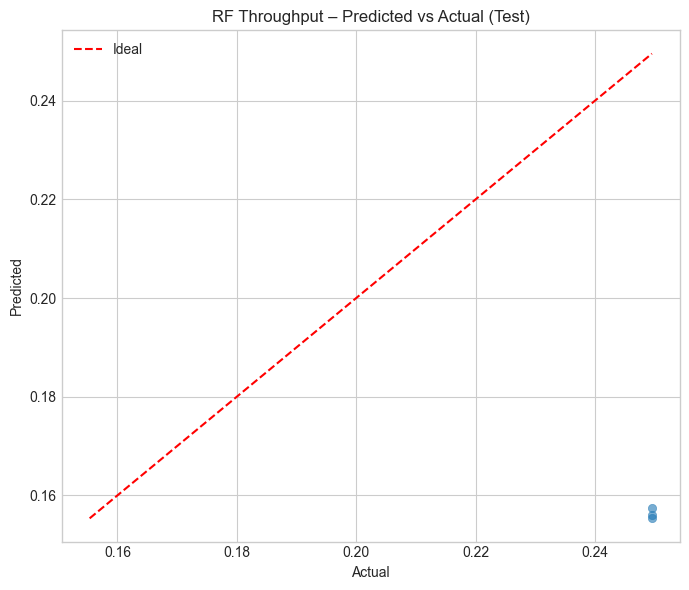

Saved → ../outputs/models/plots/rf_Throughput_pred_vs_actual_test.png


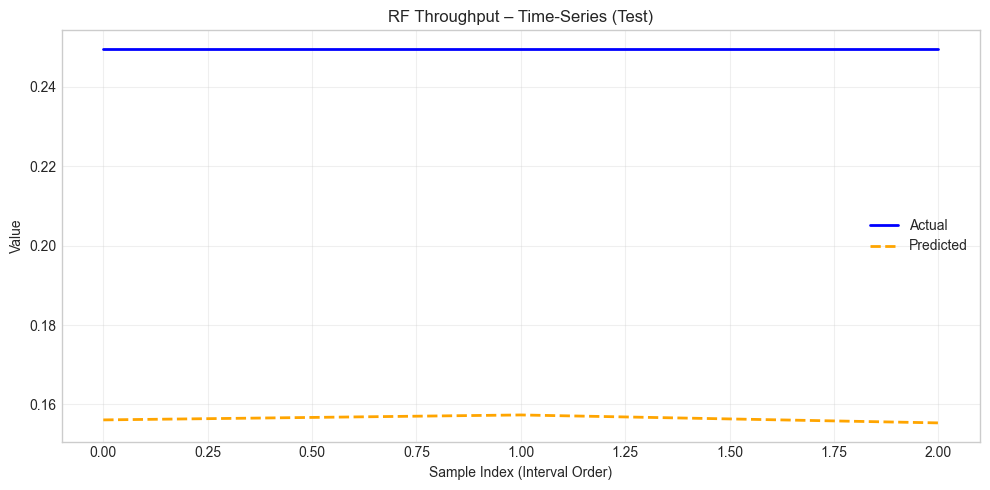

Saved → ../outputs/models/plots/rf_Throughput_timeseries_test.png

=== RF Plots for Latency ===


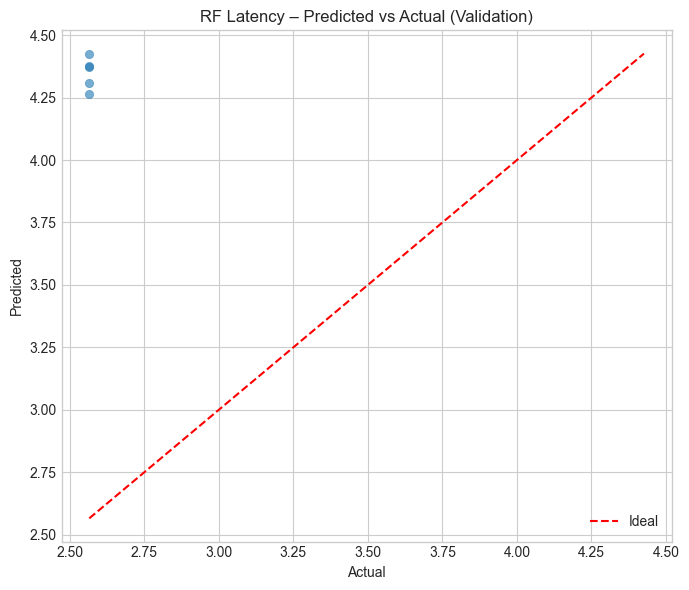

Saved → ../outputs/models/plots/rf_Latency_pred_vs_actual_valid.png


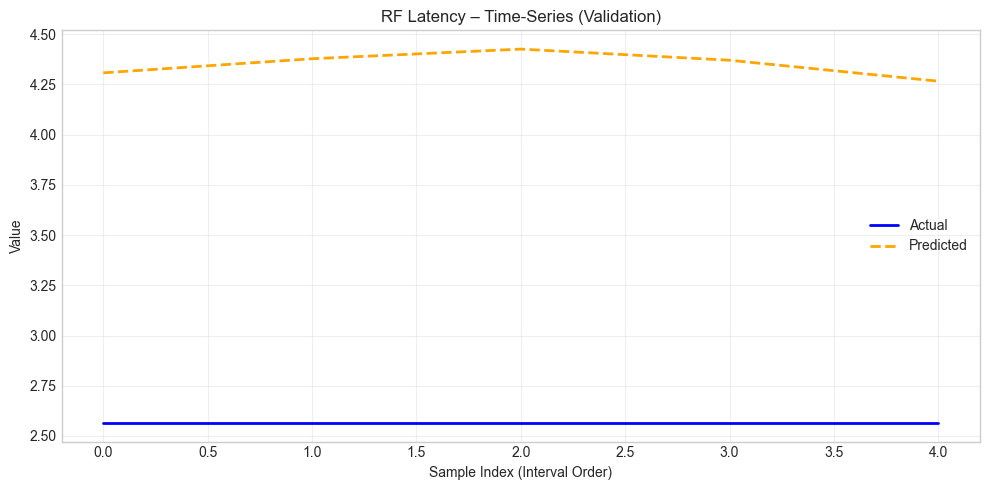

Saved → ../outputs/models/plots/rf_Latency_timeseries_valid.png


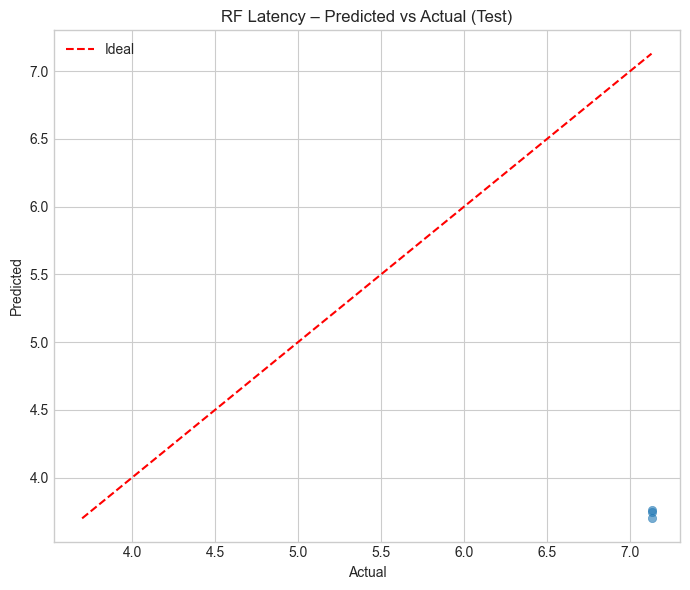

Saved → ../outputs/models/plots/rf_Latency_pred_vs_actual_test.png


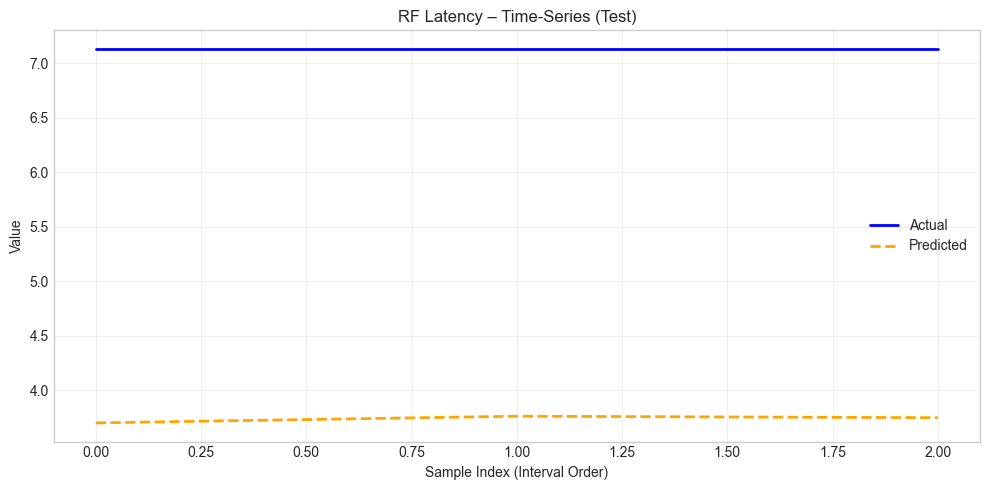

Saved → ../outputs/models/plots/rf_Latency_timeseries_test.png

=== RF Plots for Loss ===


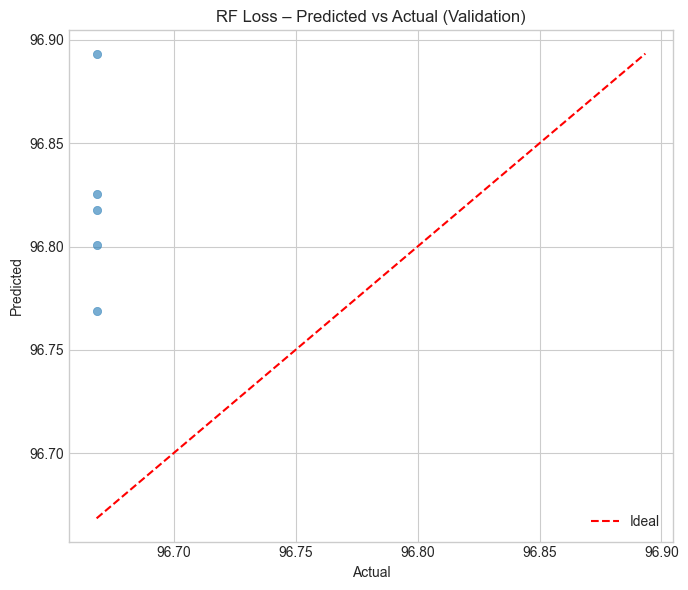

Saved → ../outputs/models/plots/rf_Loss_pred_vs_actual_valid.png


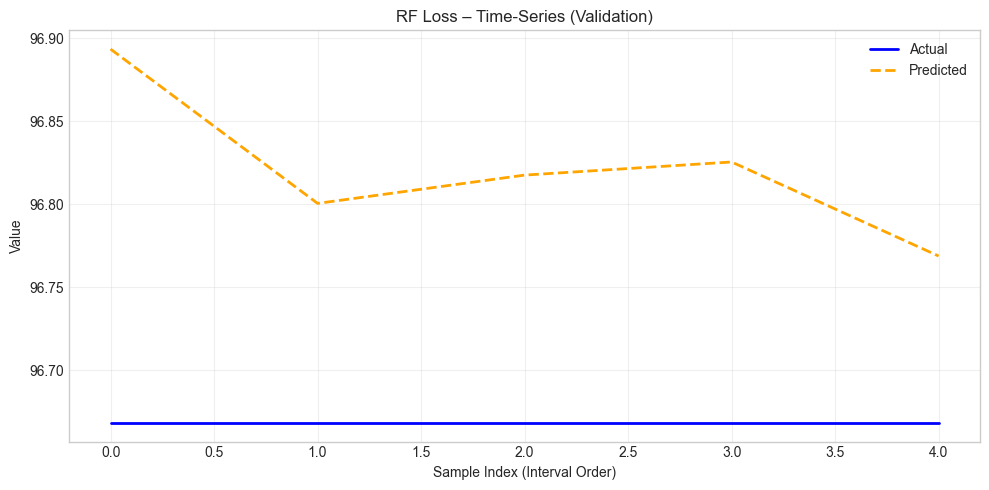

Saved → ../outputs/models/plots/rf_Loss_timeseries_valid.png


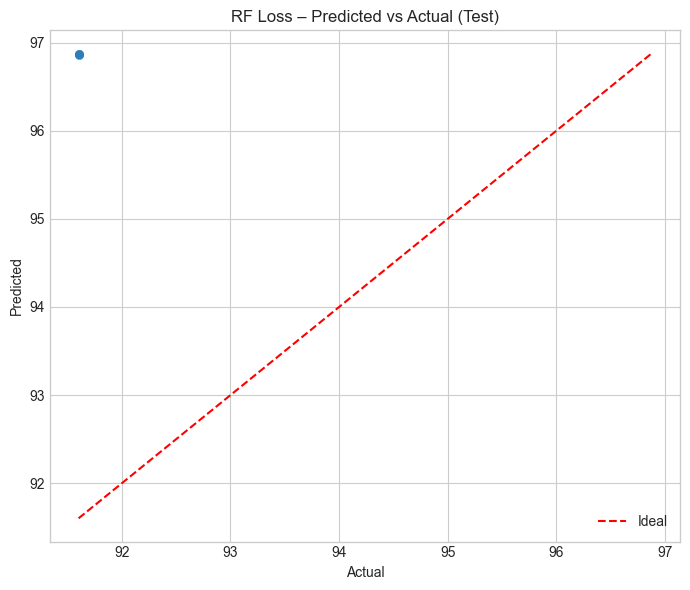

Saved → ../outputs/models/plots/rf_Loss_pred_vs_actual_test.png


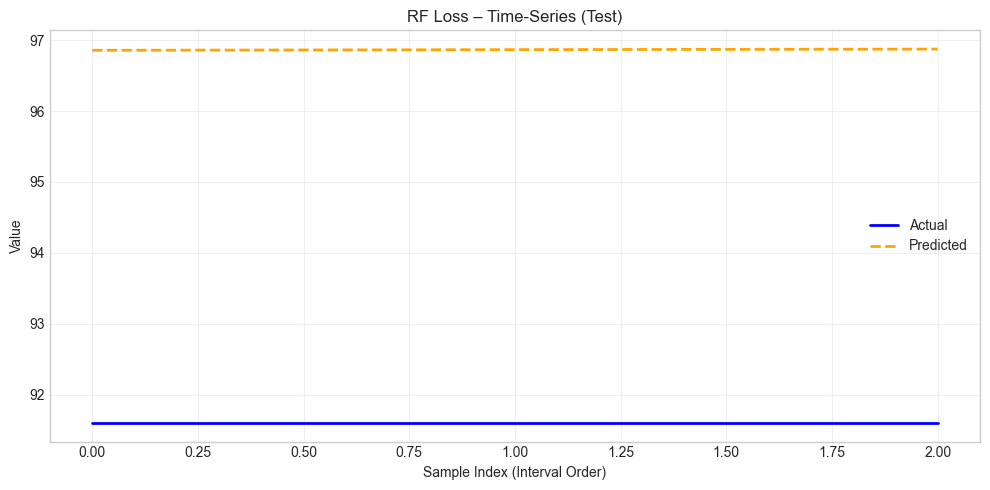

Saved → ../outputs/models/plots/rf_Loss_timeseries_test.png

All RF plots generated!


In [3]:
# from rf_plots import generate_rf_plots

generate_rf_plots(showImage=True)


In [6]:
import os
import time
import joblib
import numpy as np
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# =====================================================================
# 1. Load RF Model From Path
# =====================================================================

def load_rf_model(model_path):
    """
    Load RandomForestRegressor and expose trained feature count.
    """
    model = joblib.load(model_path)

    if not hasattr(model, "n_features_in_"):
        raise ValueError("RF model does not expose n_features_in_")

    return model, model.n_features_in_



# =====================================================================
# 2. Count Parameters, Nodes, Tree Depth
# =====================================================================

def rf_structure_stats(rf: RandomForestRegressor):
    """
    Extracts RF structural complexity:
    - number of trees
    - nodes per tree
    - average depth
    - total nodes
    """
    n_trees = len(rf.estimators_)
    nodes_per_tree = []
    depth_per_tree = []

    for tree in rf.estimators_:
        t = tree.tree_
        nodes_per_tree.append(t.node_count)
        depth_per_tree.append(t.max_depth)

    return {
        "n_trees": n_trees,
        "avg_nodes_per_tree": float(np.mean(nodes_per_tree)),
        "total_nodes": int(np.sum(nodes_per_tree)),
        "avg_tree_depth": float(np.mean(depth_per_tree)),
        "max_tree_depth": int(np.max(depth_per_tree)),
    }


# =====================================================================
# 3. Model Size in Bytes
# =====================================================================

def rf_model_size_bytes(model_path):
    """
    Model size on disk = true storage cost.
    """
    size = os.path.getsize(model_path)
    return size, size / (1024 * 1024)  # bytes, MB


# =====================================================================
# 4. Inference Latency Measurement
# =====================================================================

def measure_rf_latency(rf_model, X_sample, runs=200, warmup=20):
    """
    Measures RF inference latency using real CPU time.

    X_sample: shape (1, n_features)
    """

    # Warmup
    for _ in range(warmup):
        _ = rf_model.predict(X_sample)

    t0 = time.perf_counter()
    for _ in range(runs):
        _ = rf_model.predict(X_sample)
    t1 = time.perf_counter()

    return (t1 - t0) / runs


# =====================================================================
# 5. Energy Estimate
# =====================================================================

def estimate_energy(latency_s, assumed_power_W=2.0):
    """
    E = Power × Latency
    (Use estimated power if real measurement unavailable)
    """
    return latency_s * assumed_power_W


# =====================================================================
# 6. Full RF Edge Evaluation
# =====================================================================
def validate_rf_input(rf_model, X_sample):
    expected = rf_model.n_features_in_
    actual = X_sample.shape[1]

    if actual != expected:
        raise ValueError(
            f"RF input feature mismatch: expected {expected}, got {actual}"
        )


def evaluate_rf_edge(model_path, X_sample, assumed_power_W=2.0):
    """
    Full RF edge efficiency evaluation with feature validation.
    """

    rf_model, input_dim = load_rf_model(model_path)

    # Enforce correct feature dimensionality
    validate_rf_input(rf_model, X_sample)

    # Structure stats
    structure = rf_structure_stats(rf_model)

    # True model size (on disk)
    size_bytes, size_mb = rf_model_size_bytes(model_path)

    # Latency (measured)
    latency = measure_rf_latency(rf_model, X_sample)

    # Energy
    energy = estimate_energy(latency, assumed_power_W)

    # RF has no activations; peak memory ≈ input buffer
    peak_activation_bytes = X_sample.nbytes

    return {
        "Input Dim": input_dim,
        "Trees": structure["n_trees"],
        "Total Nodes": structure["total_nodes"],
        "Average Nodes per Tree": structure["avg_nodes_per_tree"],
        "Average Tree Depth": structure["avg_tree_depth"],
        "Max Tree Depth": structure["max_tree_depth"],
        "Model Size (Bytes)": size_bytes,
        "Model Size (MB)": size_mb,
        "Latency (s)": latency,
        "Latency (ms)": latency * 1000,
        "Energy Estimated (J)": energy,
        "Peak Activation Memory (Bytes)": peak_activation_bytes
    }



In [8]:
# from rf_edge_evaluation import evaluate_rf_edge
import numpy as np

model_path = "../outputs/models/rf_model_throughput.pkl"

# one sample input with correct feature dimension
X_sample = np.random.randn(1, 73)

metrics = evaluate_rf_edge(model_path, X_sample)

for k, v in metrics.items():
    print(f"{k}: {v}")


Input Dim: 73
Trees: 300
Total Nodes: 1500
Average Nodes per Tree: 5.0
Average Tree Depth: 2.0
Max Tree Depth: 2
Model Size (Bytes): 204161
Model Size (MB): 0.1947031021118164
Latency (s): 0.05525071692500205
Latency (ms): 55.25071692500205
Energy Estimated (J): 0.1105014338500041
Peak Activation Memory (Bytes): 584
